# RF Circuit Simulation: Balanced double-resonance LC circuit

### Figure 7, Ref: A practical introduction to radio frequency electronics for NMR probe builders, Jose L. Uribe, Rachel W. Martin, Journal of Magnetic Resonance Open 19 (2024) 100153.

### Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay (vineeth.thalakottoor@cea.fr)

In [1]:
# Define the source path
SourcePath = "/home/vineeth/Documents/PyOR/PyOR"

# Add source path
import sys
sys.path.append(SourcePath)

import time
%matplotlib inline

# Import PyOR package
from PyORv2 import *


*****        ***** *****
*   *        *   * *   *
*****  *   * *   * *****
*       * *  *   * * *  
*        *   ***** *  * 
        *               
       *                
Welcome to Python On Resonance (PyOR)

"In everlasting memory of Gauri, who led me from untruth to Truth, from darkness to Light, and from death to Immortality."

Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay

Email: vineeth.thalakottoor@cea.fr

"Everybody can simulate Magnetic Resonance"

Imported modules:

* QuantumSystem          (QuantumSystem from PyOR_QuantumSystem - for single quantum system)
* QuantumSystems         (QuantumSystems from PyOR_QuantumSystems - for multiple quantum systems)
** Hamiltonian           (from PyOR_Hamiltonian)
** DensityMatrix         (from PyOR_DensityMatrix)
** HardPulse             (from PyOR_HardPulse)
** Basis                 (from PyOR_Basis)
** RelaxationProcess     (from PyOR_Relaxation)
** Evolutions            (from PyOR_Evolution)
** Plotting          

## Define ports and components

P1-P4 are physical port labels. N1/N2 are electrical connection nodes; J1-J5 are internal junctions and P0 is ground. Component endpoints use the same node names.


In [2]:
# Physical port label and electrical connection node.
ports = [
    ("P1", "N1"),  # Port 1 -> node N1
    ("P2", "N2"),  # Port 2 -> node N2
    ("P3", "N2"),  # Port 3 -> node N2 (shared with port 2)
    ("P4", "N1"),  # Port 4 -> node N1 (shared with port 1)
]
Z0 = 50.0

# Plot limits: MHz and dB. None selects automatic limits.
Frequency_Limits = (100, 550)
Magnitude_Limits = (-60, 5)

components = [
    Element("C1_HM",     "C", "N1", "J1", 0.3045, "pF"),
    Element("C2_HT",     "C", "J1", "P0", 2.998,  "pF"),
    Element("C_trap1",   "C", "J1", "J2", 31.9,   "pF"),
    Element("L_trap1",   "L", "J2", "P0", 50.0,   "nH"),
    Element("C_Balance", "C", "J1", "J3", 31.007, "pF"),
    Element("L_Sample",  "L", "J3", "J4", 125.0,  "nH"),
    Element("H_Balance", "C", "J4", "P0", 3.091,  "pF"),
    Element("LH_trap",   "L", "J4", "J5", 50.0,   "nH"),
    Element("CH_trap",   "C", "J4", "J5", 2.03,   "pF"),
    Element("C2",        "C", "J5", "P0", 10.41,  "pF"),
    Element("C1",        "C", "J5", "N2", 1.4549, "pF"),
]

circuit = RFCircuit(components, ports, z0=Z0,
                    title="Balanced series-trap circuit — four ports")
print(circuit.title)
for number, (label, node) in enumerate(circuit.port_definitions, start=1):
    print(f"Port {number} ({label}) -> node {node}; reference node P0")
print("All electrical nodes:", circuit.nodes)
print("Reference impedance:", circuit.z0, "Ω")


Balanced series-trap circuit — four ports
Port 1 (P1) -> node N1; reference node P0
Port 2 (P2) -> node N2; reference node P0
Port 3 (P3) -> node N2; reference node P0
Port 4 (P4) -> node N1; reference node P0
All electrical nodes: ['N1', 'N2', 'J1', 'P0', 'J2', 'J3', 'J4', 'J5']
Reference impedance: 50.0 Ω


## Plotting

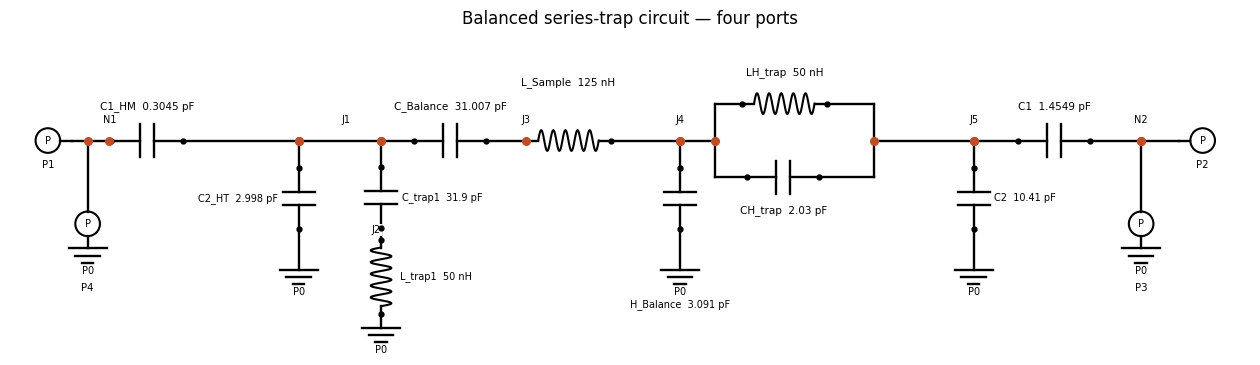

In [3]:
circuit.Plot_Circuit(figsize=(16, 5))
RFCircuit.Show()

## Optional JSON loading and saving

Uncomment loading to replace the circuit defined above with a saved circuit before simulation. Uncomment saving after simulation to include sweep settings.


In [4]:
# Load an existing circuit parameter JSON file:
# circuit = RFCircuit.Load_Parameters("RF_Circuit_Parameters.json")

# Save the current circuit parameters:
# circuit.Save_Parameters("RF_Circuit_Parameters.json")


## Simulate and draw the circuit


In [5]:
frequency, S = circuit.Simulate(
    start="100MHz",
    stop="550MHz",
    points=3001,
    logarithmic=True,
    refine=True,
)
print(f"{len(frequency):,} frequency samples; S shape = {S.shape}")



27,001 frequency samples; S shape = (27001, 4, 4)


## S parameters

The magnitude plot shows S14, S23, S21 and S12. Edit the limits below or set them to None for automatic limits.

The y-limits are set separately for the selected frequency windows: S14/S23 use -60 to 5 dB, S12 uses -130 to -55 dB, and S21 uses -155 to -50 dB. These limits include each sampled minimum with space around the curves; they do not change the calculated S values.


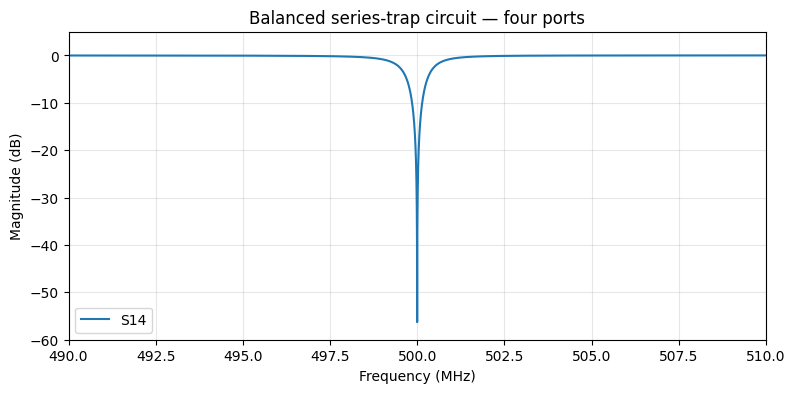

In [6]:
circuit.Plot_Sparameter(
    ["S14"],
    xlim=(490,510),
    ylim=(-60, 5),
)
RFCircuit.Show()


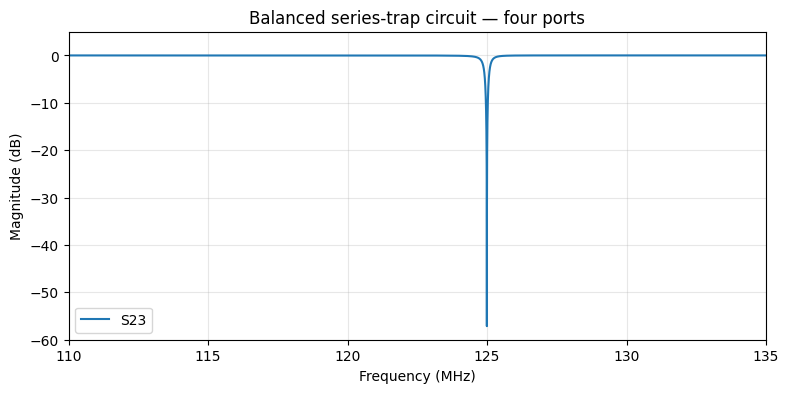

In [7]:
circuit.Plot_Sparameter(
    ["S23"],
    xlim=(110,135),
    ylim=(-60, 5),
)
RFCircuit.Show()

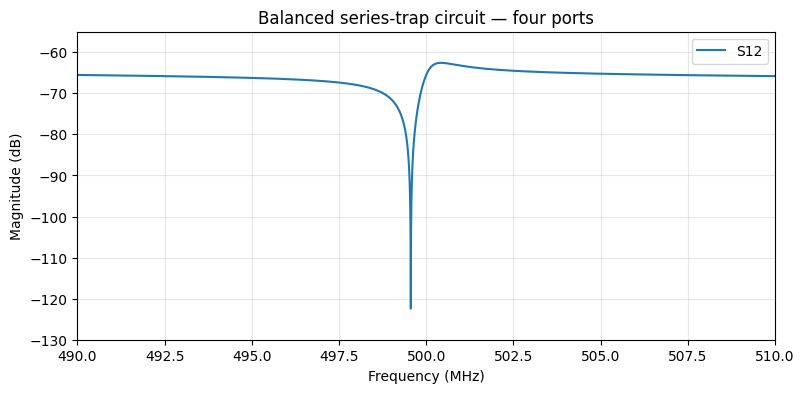

In [8]:
circuit.Plot_Sparameter(
    ["S12"],
    xlim=(490,510),
    ylim=(-130, -55),
)
RFCircuit.Show()

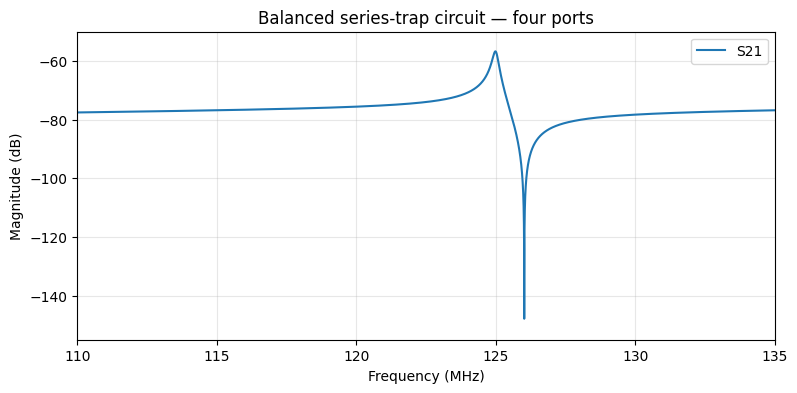

In [9]:
circuit.Plot_Sparameter(
    ["S21"],
    xlim=(110,135),
    ylim=(-155, -50),
)
RFCircuit.Show()